# Gaussian Process Regression Tutorial
Model smooth uncertainty-aware regression with DeepUQ's custom Gaussian Process implementation.

## Goal
Fit a Gaussian Process to noisy one-dimensional data, visualise posterior predictions, and quantify uncertainty.

In [1]:
# Configure Python path so the notebook sees the local deepuq package
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd())
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = str(PROJECT_ROOT / 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from deepuq.models import GaussianProcessRegressor, RBFKernel

## Generate Data
We sample noisy observations from a sinusoidal function and reserve a dense grid for evaluation.

In [3]:
torch.manual_seed(42)
np.random.seed(42)

def toy_function(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(1.5 * math.pi * x)

x_train = torch.linspace(-1.0, 1.0, 24).unsqueeze(-1)
y_clean = toy_function(x_train)
noise = 0.1 * torch.randn_like(y_clean)
y_train = y_clean + noise

x_test = torch.linspace(-1.5, 1.5, 200).unsqueeze(-1)
y_test = toy_function(x_test)

x_train[:5], y_train[:5]

(tensor([[-1.0000],
         [-0.9130],
         [-0.8261],
         [-0.7391],
         [-0.6522]]),
 tensor([[ 1.1927e+00],
         [ 1.0659e+00],
         [ 7.7262e-01],
         [ 1.2433e-01],
         [-4.0070e-04]]))

## Fit the Gaussian Process
We adopt an RBF kernel with adjustable lengthscale and signal variance, then optimise the posterior in closed form.

In [4]:
kernel = RBFKernel(lengthscale=0.4, outputscale=1.2, jitter=1e-5)
gp = GaussianProcessRegressor(kernel=kernel, noise=0.02)
gp.fit(x_train, y_train)
log_mll = gp.log_marginal_likelihood()
print(f'Log marginal likelihood: {log_mll:.3f}')

Log marginal likelihood: 2.463


## Posterior Prediction
Compute the posterior mean and uncertainty on the test grid and draw a few function samples.

In [5]:
with torch.no_grad():
    mean, var = gp.predict(x_test)
    samples = gp.posterior_samples(x_test, n_samples=5)
mean = mean.cpu()
std = var.clamp_min(0.0).sqrt().cpu()
samples = samples.cpu()
x_test_np = x_test.squeeze(-1).cpu().numpy()
x_train_np = x_train.squeeze(-1).cpu().numpy()
y_train_np = y_train.squeeze(-1).cpu().numpy()
y_test_np = y_test.squeeze(-1).cpu().numpy()


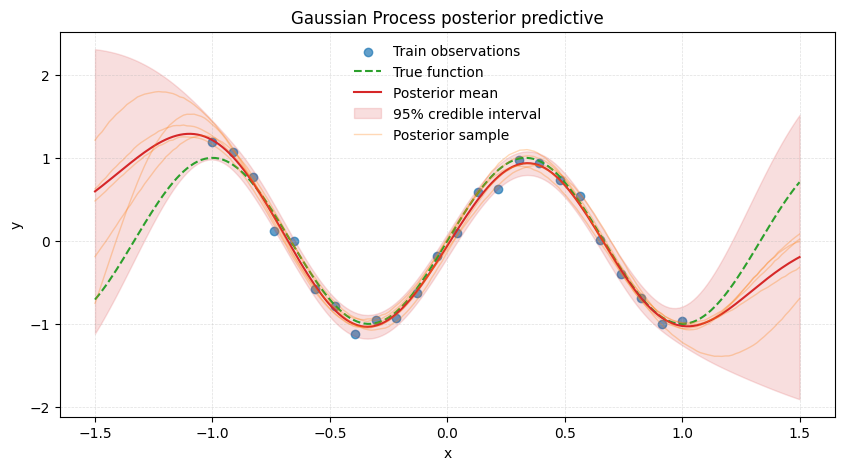

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(x_train_np, y_train_np, color='tab:blue', label='Train observations', alpha=0.7)
plt.plot(x_test_np, y_test_np, color='tab:green', linestyle='--', label='True function')
plt.plot(x_test_np, mean.numpy(), color='tab:red', label='Posterior mean')
plt.fill_between(x_test_np, mean.numpy() - 2 * std.numpy(), mean.numpy() + 2 * std.numpy(),
                 color='tab:red', alpha=0.15, label='95% credible interval')
for idx, sample in enumerate(samples):
    plt.plot(x_test_np, sample.numpy(), color='tab:orange', alpha=0.3, linewidth=1.0, label='Posterior sample' if idx == 0 else None)
plt.legend(frameon=False)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gaussian Process posterior predictive')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.show()

## Quantitative Check
We estimate the root-mean-squared-error of the posterior mean and average predictive uncertainty.

In [7]:
rmse = torch.sqrt(torch.mean((mean - y_test.squeeze(-1).cpu())**2))
avg_uncertainty = std.mean()
print(f'Posterior mean RMSE: {rmse:.4f}')
print(f'Average predictive std: {avg_uncertainty:.4f}')

Posterior mean RMSE: 0.4004
Average predictive std: 0.2087
